# Setting up the environment

## Importing libraries

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
import os

from scipy import stats
from keras.datasets import imdb
from keras.preprocessing.sequence import pad_sequences

from keras.callbacks import EarlyStopping
from keras.models import Sequential
from keras.layers import Embedding, SimpleRNN, Dense, Dropout, LayerNormalization

## Downloading the IMDB dataset

In [2]:
(X_train, y_train), (X_test, y_test) = imdb.load_data()
print(X_train.shape)
print(X_test.shape)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(25000,)
(25000,)


In [ ]:
print(X_train[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 22665, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 21631, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 19193, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 10311, 8, 4, 107, 117, 5952, 15, 256, 4, 31050, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 12118, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]


# Exploratory data analysis

## Unique values and counts in training and testing datsets

In [ ]:
unique_train, counts_train = np.unique(y_train, return_counts=True)
unique_test, counts_test = np.unique(y_test, return_counts=True)

print("y_train distribution:", dict(zip(unique_train, counts_train)))
print("y_test distribution:", dict(zip(unique_test, counts_test)))

y_train distribution: {0: 12500, 1: 12500}
y_test distribution: {0: 12500, 1: 12500}


## Distributuon of labels in training and testing datasets

In [ ]:
# Create a DataFrame for plotting
data = {
    'Dataset': ['y_train'] * len(unique_train) + ['y_test'] * len(unique_test),
    'Label': np.concatenate((unique_train, unique_test)),
    'Count': np.concatenate((counts_train, counts_test))
}

df = pd.DataFrame(data)
display(df)

,Dataset,Label,Count
0,y_train,0,12500
1,y_train,1,12500
2,y_test,0,12500
3,y_test,1,12500


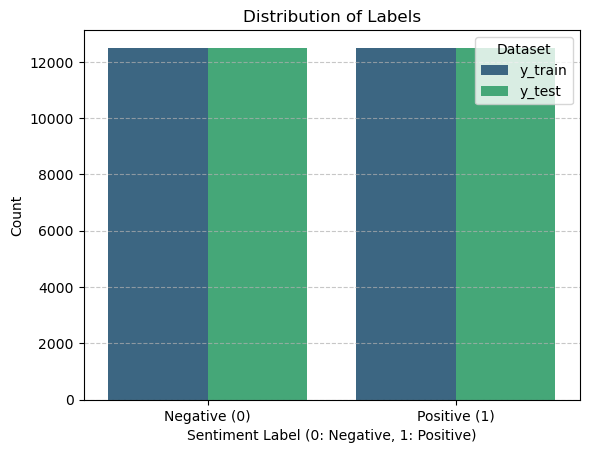

In [ ]:
plt.figure()

sns.barplot(x='Label', y='Count', hue='Dataset', data=df, palette='viridis')
plt.title('Distribution of Labels')
plt.xlabel('Sentiment Label (0: Negative, 1: Positive)')
plt.ylabel('Count')

plt.xticks([0, 1], ['Negative (0)', 'Positive (1)'])
plt.legend(title='Dataset')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Distributuon of review lengths in training and testing datasets

In [ ]:
len_train = list(map(len, X_train))
len_test = list(map(len, X_test))

print(f"X_train - max: {max(len_train)}, min: {min(len_train)}")
print(f"X_test - max: {max(len_test)}, min: {min(len_test)}")

X_train - max: 2494, min: 11
X_test - max: 2315, min: 7


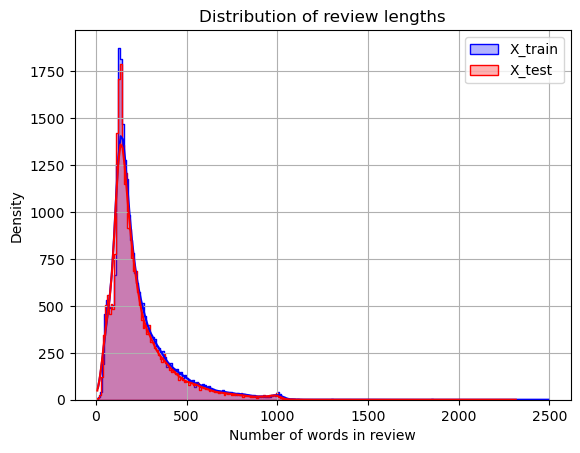

In [ ]:
sns.histplot(len_train, color='blue', alpha=0.3, label='X_train', kde=True, element='step')
sns.histplot(len_test, color='red', alpha=0.3, label='X_test', kde=True, element='step')

plt.xlabel("Number of words in review")
plt.ylabel("Density") # Changed from Probability as histplot with kde shows density
plt.title("Distribution of review lengths")

plt.legend()
plt.grid()
plt.show()

## Extracting word indices

In [ ]:
word_index = imdb.get_word_index()
# print(word_index)
print("Length of word_index:", len(word_index))

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Length of word_index: 88584


## Decoding reviews

In [ ]:
def whatItsays(index=0, width=75):
    reverse_index = dict([(value, key) for (key, value) in word_index.items()])
    review = ''

    for i in X_train[index]:
        word = reverse_index.get(i-3, "!")
        review = review + word + " "

    # Wrap the text using textwrap.fill()
    wrapped_review = textwrap.fill(review[:-1], width=width)
    return wrapped_review

print(whatItsays())

! this film was just brilliant casting location scenery story direction
everyone's really suited the part they played and you could just imagine
being there robert redford's is an amazing actor and now the same being
director norman's father came from the same scottish island as myself so i
loved the fact there was a real connection with this film the witty remarks
throughout the film were great it was just brilliant so much that i bought
the film as soon as it was released for retail and would recommend it to
everyone to watch and the fly fishing was amazing really cried at the end
it was so sad and you know what they say if you cry at a film it must have
been good and this definitely was also congratulations to the two little
boy's that played the part's of norman and paul they were just brilliant
children are often left out of the praising list i think because the stars
that play them all grown up are such a big profile for the whole film but
these children are amazing and should be

# Pre-processing

## Extracting most frequent words

In [2]:
NUM_WORDS = 15000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=NUM_WORDS)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Padding

In [3]:
MAXLEN = 150
X_train_pad = pad_sequences(X_train, maxlen=MAXLEN, padding='post')
X_test_pad = pad_sequences(X_test, maxlen=MAXLEN, padding='post')

print(X_train_pad.shape)
print(X_test_pad.shape)

(25000, 150)
(25000, 150)


In [ ]:
len(X_train_pad[0])

150

## Dimension of word embeddings

In [4]:
VEC_DIM = 64

# MODEL 1: Recurrent Neural Network (RNN)

## Building the model

In [ ]:
RNN_DROPOUT1 = 0.3
RNN_DROPOUT2 = 0.2
RNN_DROPOUT3 = 0.2

model1 = Sequential([Embedding(NUM_WORDS, VEC_DIM),

                     SimpleRNN(32, return_sequences=True, activation='relu', kernel_initializer='he_normal'),
                     Dropout(RNN_DROPOUT1),
                     LayerNormalization(),

                     SimpleRNN(16, return_sequences=True, activation='relu', kernel_initializer='he_normal'),
                     Dropout(RNN_DROPOUT2),
                     LayerNormalization(),

                     SimpleRNN(8, return_sequences=False, activation='relu', kernel_initializer='he_normal'),
                     Dropout(RNN_DROPOUT3),
                     LayerNormalization(),

                     Dense(1, activation='sigmoid')])

# Explicitly build the model with the input shape (batch_size, maxlen)
# None for batch_size indicates it can be flexible.
model1.build((None, MAXLEN))
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 64)        │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 150, 32)        │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 150, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 150, 32)        │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 150, 16)        │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 150, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 150, 16)        │            32 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 8)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 8)              │            16 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 964,209 (3.68 MB)

 Trainable params: 964,209 (3.68 MB)

 Non-trainable params: 0 (0.00 B)

## Compiling and training

In [ ]:
EPOCHS = 10

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss',
                               min_delta=1e-4,
                               verbose=1,
                               mode="auto",
                               restore_best_weights=True,
                               patience=3)

model1.compile(loss='binary_crossentropy', optimizer='rmsprop', metrics=['accuracy'])
history1 = model1.fit(X_train_pad, y_train, validation_data=(X_test_pad, y_test), epochs=EPOCHS, callbacks=[early_stopping])

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 48ms/step - accuracy: 0.5205 - loss: 0.7131 - val_accuracy: 0.5684 - val_loss: 0.6751
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.6210 - loss: 0.6493 - val_accuracy: 0.7472 - val_loss: 0.5514
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.7393 - loss: 0.5581 - val_accuracy: 0.7639 - val_loss: 0.5147
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.7559 - loss: 0.5387 - val_accuracy: 0.7858 - val_loss: 0.4862
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.7945 - loss: 0.4917 - val_accuracy: 0.8224 - val_loss: 0.4426
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.8058 - loss: 0.4611 - val_accuracy: 0.8321 - val_loss: 0.4176
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.8151 - loss: 0.4559 - val_accuracy: 0.8049 - val_loss: 0.4586
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.8334 - loss: 0.4200 - 

## Plotting model metrics

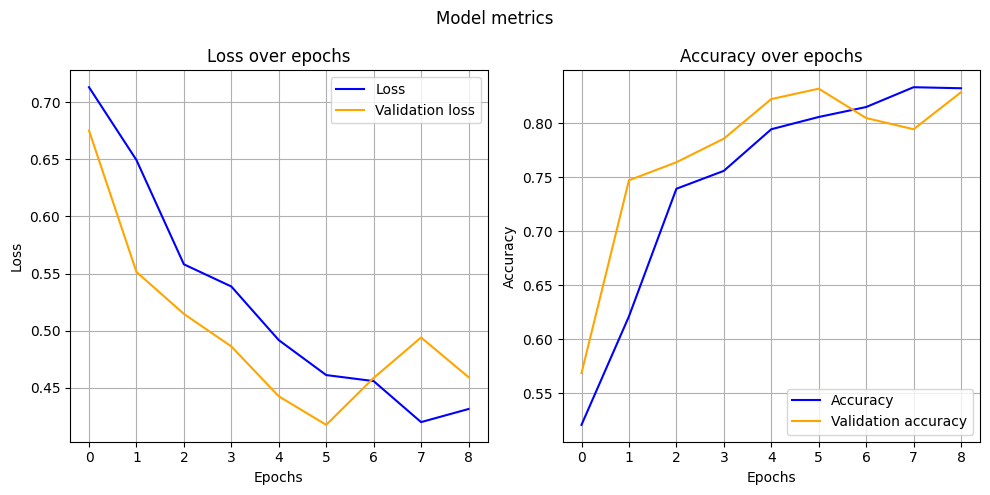

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
parameters1 = {'drop1': RNN_DROPOUT1, 'drop2': RNN_DROPOUT2, 'drop3': RNN_DROPOUT3}
# Loss
ax[0].plot(history1.history['loss'], color='blue', label='Loss')
ax[0].plot(history1.history['val_loss'], color='orange', label='Validation loss')
ax[0].set_title("Loss over epochs")
ax[0].set_ylabel("Loss")
ax[0].set_xlabel("Epochs")
ax[0].legend()
ax[0].grid()

# Accuracy
ax[1].plot(history1.history['accuracy'], color='blue', label='Accuracy')
ax[1].plot(history1.history['val_accuracy'], color='orange', label='Validation accuracy')
ax[1].set_title("Accuracy over epochs")
ax[1].set_ylabel("Accuracy")
ax[1].set_xlabel("Epochs")
ax[1].legend()
ax[1].grid()

fig.suptitle(f"Model metrics ({parameters1})")
fig.tight_layout()
plt.show()

# Saving figure
count = 1
model_type = 'rnn'
filename = f'{model_type}-{count}.png'

while os.path.exists(filename):
    count += 1
    filename = f'{model_type}-{count}.png'
    
plt.savefig(filename)

## Checking accuracy

In [ ]:
score = model1.evaluate(X_test_pad, y_test)
print("Accuracy:", score[1]*100)

782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8321 - loss: 0.4176
Accuracy: 83.20800065994263


## Saving the model

In [ ]:
# Saving model
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
count = 1
filename = f'/content/drive/MyDrive/models/sentiment-analysis/{model_type}-{count}.keras'

while os.path.exists(filename):
    count += 1
    filename = f'/content/drive/MyDrive/models/sentiment-analysis/{model_type}-{count}.keras'
    
model1.save(filename)

# MODEL 2: Long Short-Term Memory (LSTM)

## Preparing the model

In [ ]:
from keras.layers import LSTM, SpatialDropout1D
LSTM_OUT = 128

LSTM_SPATIAL_DROPOUT = 0.4
LSTM_DROPOUT = 0.3
LSTM_RECURRENT_DROPOUT = 0.3
# Spatial dropout removes the same embedding dimension for all the words in a sentence.
# Word1 -> [0.2, 0, 0.7, 0.1]
# Word2 -> [0.8, 0, 0.3, 0.9]
# Word3 -> [0.6, 0, 0.2, 0.4]

# dropout removes the same embedding from the input for all the words in a sequence
# recurrent dropout removes the same embedding from the hidden state for all words in a sequence
model2 = Sequential([Embedding(NUM_WORDS, VEC_DIM),
					 SpatialDropout1D(LSTM_SPATIAL_DROPOUT),

                     LSTM(LSTM_OUT, dropout=LSTM_DROPOUT, recurrent_dropout=LSTM_RECURRENT_DROPOUT),
                     Dense(1, activation='sigmoid')])

model2.build((None, MAXLEN))
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 150, 64)        │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 150, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,058,945 (4.04 MB)

 Trainable params: 1,058,945 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

## Compiling and training

In [ ]:
EPOCHS = 5

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss',
                               min_delta=1e-4,
                               verbose=1,
                               mode="auto",
                               restore_best_weights=True,
                               patience=2)

model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history2 = model2.fit(X_train_pad, y_train, validation_data=(X_test_pad, y_test), epochs=EPOCHS, callbacks=[early_stopping])

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 495s 629ms/step - accuracy: 0.6323 - loss: 0.6311 - val_accuracy: 0.7390 - val_loss: 0.5525
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 487s 623ms/step - accuracy: 0.7320 - loss: 0.5358 - val_accuracy: 0.7549 - val_loss: 0.5287
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 489s 625ms/step - accuracy: 0.8534 - loss: 0.3556 - val_accuracy: 0.8645 - val_loss: 0.3221
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 493s 630ms/step - accuracy: 0.9025 - loss: 0.2522 - val_accuracy: 0.8733 - val_loss: 0.3099
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 496s 622ms/step - accuracy: 0.9275 - loss: 0.1949 - val_accuracy: 0.8681 - val_loss: 0.3491
Restoring model weights from the end of the best epoch: 4.


## Plotting model metrics

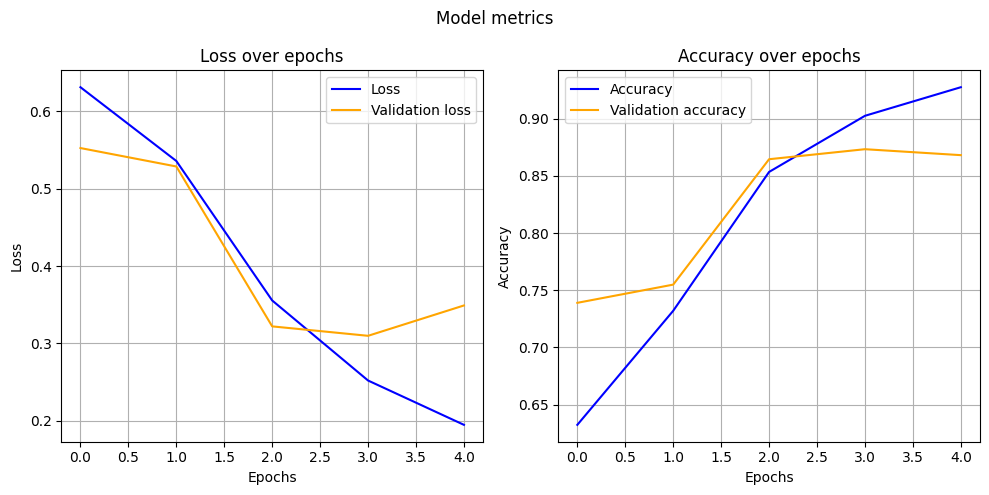

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
parameters2 = {'spat_drop': LSTM_SPATIAL_DROPOUT, 'drop': LSTM_DROPOUT, 'rec_drop': LSTM_RECURRENT_DROPOUT}

# Loss
ax[0].plot(history2.history['loss'], color='blue', label='Loss')
ax[0].plot(history2.history['val_loss'], color='orange', label='Validation loss')
ax[0].set_title("Loss over epochs")
ax[0].set_ylabel("Loss")
ax[0].set_xlabel("Epochs")
ax[0].legend()
ax[0].grid()

# Accuracy
ax[1].plot(history2.history['accuracy'], color='blue', label='Accuracy')
ax[1].plot(history2.history['val_accuracy'], color='orange', label='Validation accuracy')
ax[1].set_title("Accuracy over epochs")
ax[1].set_ylabel("Accuracy")
ax[1].set_xlabel("Epochs")
ax[1].legend()
ax[1].grid()

fig.suptitle(F"Model metrics ({parameters2})")
fig.tight_layout()

# Saving figure
count = 1
model_type = 'lstm'
filename = f'{model_type}-{count}.png'


while os.path.exists(filename):
    count += 1
    filename = f'{model_type}-{count}.png'
    
plt.savefig(filename)

## Checking accuracy

In [ ]:
score = model2.evaluate(X_test_pad, y_test)
print("Accuracy:", score[1]*100)

782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 103ms/step - accuracy: 0.8733 - loss: 0.3099
Accuracy: 87.32799887657166


## Saving the model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
count = 1
filename = f'/content/drive/MyDrive/models/sentiment-analysis/{model_type}-{count}.keras'

while os.path.exists(filename):
    count += 1
    filename = f'/content/drive/MyDrive/models/sentiment-analysis/{model_type}-{count}.keras'
    
model2.save(filename)

# MODEL 3: Gated Recurrent Unit (GRU)

## Building the model

In [47]:
from keras.layers import GRU, SpatialDropout1D
GRU_OUT = 128
GRU_SPATIAL_DROPOUT = 0.4
GRU_RECURRENT_DROPOUT = 0.3
GRU_DROPOUT = 0.3

model3 = Sequential([Embedding(NUM_WORDS, VEC_DIM),
                     SpatialDropout1D(GRU_SPATIAL_DROPOUT),
                     GRU(GRU_OUT, dropout=GRU_DROPOUT, recurrent_dropout=GRU_RECURRENT_DROPOUT),
                     Dense(1, activation='sigmoid')])

model3.build((None, MAXLEN))
model3.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 150, 64)        │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_7             │ (None, 150, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_7 (GRU)                     │ (None, 128)            │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,034,625 (3.95 MB)

 Trainable params: 1,034,625 (3.95 MB)

 Non-trainable params: 0 (0.00 B)

## Compiling and training

In [48]:
EPOCHS = 5

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss',
                               min_delta=1e-4,
                               verbose=1,
                               mode="auto",
                               restore_best_weights=True,
                               patience=2)

model3.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history3 = model3.fit(X_train_pad, y_train, validation_data=(X_test_pad, y_test), epochs=EPOCHS, callbacks=[early_stopping])

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 463s 588ms/step - accuracy: 0.6435 - loss: 0.6139 - val_accuracy: 0.8128 - val_loss: 0.4407
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 442s 566ms/step - accuracy: 0.8533 - loss: 0.3500 - val_accuracy: 0.8835 - val_loss: 0.2805
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 451s 577ms/step - accuracy: 0.9097 - loss: 0.2318 - val_accuracy: 0.8832 - val_loss: 0.2815
Epoch 4/5
  3/782 ━━━━━━━━━━━━━━━━━━━━ 5:28 422ms/step - accuracy: 0.9566 - loss: 0.1707

: 

## Plotting model metrics

In [1]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
parameters3 = {'spat_drop': GRU_SPATIAL_DROPOUT, 'drop': GRU_DROPOUT, 'rec_drop': GRU_RECURRENT_DROPOUT}

# Loss
ax[0].plot(history3.history['loss'], color='blue', label='Loss')
ax[0].plot(history3.history['val_loss'], color='orange', label='Validation loss')
ax[0].set_title("Loss over epochs")
ax[0].set_ylabel("Loss")
ax[0].set_xlabel("Epochs")
ax[0].legend()
ax[0].grid()

# Accuracy
ax[1].plot(history3.history['accuracy'], color='blue', label='Accuracy')
ax[1].plot(history3.history['val_accuracy'], color='orange', label='Validation accuracy')
ax[1].set_title("Accuracy over epochs")
ax[1].set_ylabel("Accuracy")
ax[1].set_xlabel("Epochs")
ax[1].legend()
ax[1].grid()

fig.suptitle(f"Model metrics ({parameters3})")
fig.tight_layout()

# Saving figure
count = 1
model_type = 'gru'
filename = f'{model_type}-{count}.png'

while os.path.exists(filename):
    count += 1
    filename = f'{model_type}-{count}.png'
    
plt.savefig(filename)

NameError: name 'plt' is not defined

## Checking accuracy

In [43]:
score = model3.evaluate(X_test_pad, y_test)
print("Accuracy:", score[1]*100)

782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 107ms/step - accuracy: 0.8772 - loss: 0.2876
Accuracy: 87.72000074386597


## Saving the model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
count = 1
filename = f'/content/drive/MyDrive/models/sentiment-analysis/{model_type}-{count}.keras'

while os.path.exists(filename):
    count += 1
    filename = f'/content/drive/MyDrive/models/sentiment-analysis/{model_type}-{count}.keras'
    
model3.save(filename)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Predicting Review

## Score function for reviews

In [11]:
word_index = imdb.get_word_index()
NUM_WORDS = 15000
MAXLEN = 150

# Function to calculate sentiment score of review
def sentiment_score(review_text, model):
    indexed_review = []
    words = review_text.lower().split()

    # storing indices of words
    for word in words:
        word_id = word_index.get(word, 0) + 3   # shifting as per IMDB dataset

        if 3 < word_id < NUM_WORDS:     # if word is present in vocabulary
            indexed_review.append(word_id)
        else:       # if word is not present in vocabulary
            indexed_review.append(2)    # unknown token

    # Padding to match length
    padded_review = pad_sequences([indexed_review], maxlen=MAXLEN, padding='post')
    # prediction
    prediction = model.predict(padded_review)
    score = prediction[0][0]

    return score

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## RNN model

### Loading the model

In [ ]:
from keras.models import load_model
rnn = load_model(f'/content/drive/MyDrive/models/sentiment-analysis/rnn.keras')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 64)        │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 150, 32)        │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 150, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 150, 32)        │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 150, 16)        │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 150, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 150, 16)        │            32 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 8)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 8)              │            16 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,928,420 (7.36 MB)

 Trainable params: 964,209 (3.68 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 964,211 (3.68 MB)

## Inspecting the model

In [22]:
rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 64)        │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 150, 32)        │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 150, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 150, 32)        │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 150, 16)        │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 150, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 150, 16)        │            32 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 8)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 8)              │            16 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,928,420 (7.36 MB)

 Trainable params: 964,209 (3.68 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 964,211 (3.68 MB)

In [27]:
rnn.layers

[<Embedding name=embedding, built=True>,
 <SimpleRNN name=simple_rnn, built=True>,
 <Dropout name=dropout, built=True>,
 <LayerNormalization name=layer_normalization, built=True>,
 <SimpleRNN name=simple_rnn_1, built=True>,
 <Dropout name=dropout_1, built=True>,
 <LayerNormalization name=layer_normalization_1, built=True>,
 <SimpleRNN name=simple_rnn_2, built=True>,
 <Dropout name=dropout_2, built=True>,
 <LayerNormalization name=layer_normalization_2, built=True>,
 <Dense name=dense, built=True>]

In [28]:
count = 0

for layer in rnn.layers:
    if 'dropout' in layer.name:
        count += 1
        print(f"Dropout {count}: {layer.rate}")

Dropout 1: 0.3
Dropout 2: 0.2
Dropout 3: 0.2


### Making prediction

In [14]:
review_text = "The movie was not good"
score_rnn = sentiment_score(review_text, rnn)

if score_rnn>=0.5:
    print("Review is positive")
else:
    print("Review is negative")

print(f"Prediction score: {score_rnn}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Review is positive
Prediction score: 0.5345631837844849


## LSTM model

### Loading the model

In [15]:
from keras.models import load_model
lstm = load_model(f'/content/drive/MyDrive/models/sentiment-analysis/lstm.keras')

## Inspecting the model

In [29]:
lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 150, 64)        │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 150, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,176,837 (12.12 MB)

 Trainable params: 1,058,945 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,117,892 (8.08 MB)

In [30]:
lstm.layers

[<Embedding name=embedding_1, built=True>,
 <SpatialDropout1D name=spatial_dropout1d_1, built=True>,
 <LSTM name=lstm_1, built=True>,
 <Dense name=dense_1, built=True>]

In [31]:
for layer in lstm.layers:
    if 'spatial_dropout' in layer.name:
        print(f"Spatial dropout: {layer.rate}")
    elif 'lstm' in layer.name:
        print(f"Recurrent dropout: {layer.recurrent_dropout}")
        print(f"Dropout: {layer.dropout}")


Spatial dropout: 0.4
Recurrent dropout: 0.2
Dropout: 0.2


### Making prediction

In [16]:
score_lstm = sentiment_score(review_text, lstm)

if score_lstm>=0.5:
    print("Review is positive")
else:
    print("Review is negative")

print(f"Prediction score: {score_lstm}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step
Review is positive
Prediction score: 0.652915894985199


## GRU model

### Loading the model

In [ ]:
from keras.models import load_model
gru = load_model(f'/content/drive/MyDrive/models/sentiment-analysis/gru-2.keras')

## Inspecting the model

In [32]:
gru.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 150, 64)        │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 150, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,103,877 (11.84 MB)

 Trainable params: 1,034,625 (3.95 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,069,252 (7.89 MB)

In [33]:
gru.layers

[<Embedding name=embedding_1, built=True>,
 <SpatialDropout1D name=spatial_dropout1d_1, built=True>,
 <GRU name=gru_1, built=True>,
 <Dense name=dense_1, built=True>]

In [35]:
for layer in gru.layers:
    if 'spatial_dropout' in layer.name:
        print(f"Spatial dropout: {layer.rate}")
    elif 'gru' in layer.name:
        print(f"Recurrent dropout: {layer.recurrent_dropout}")
        print(f"Dropout: {layer.dropout}")

Spatial dropout: 0.2
Recurrent dropout: 0.2
Dropout: 0.2


### Making prediction

In [ ]:
review_text = "The movie was not good"
score_gru = sentiment_score(review_text, gru)

if score_gru>=0.5:
    print("Review is positive")
else:
    print("Review is negative")

print(f"Prediction score: {score_gru}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Review is positive
Prediction score: 0.5345631837844849
